# Notebook 22 — Derivative Feature Identifiability under Stronger SEI Aging

## Goal

This notebook audits whether ICA/DVA derivative voltage features under stronger SEI-only aging are stable enough to serve as fitting targets for aging-model parameterization.

The purpose is not merely to show that ICA/DVA curves can be generated. Instead, the key question is:

> Are derivative voltage features robust against smoothing-window choice, endpoint-region artifacts, and common-Q window selection?

## Porsche-oriented project relevance

This notebook addresses the model-parameterization layer of the aging-bridge project.

The Porsche PhD position emphasizes:

- electrochemical aging modeling,
- development of test methodology,
- model parameterization from measurements using optimization,
- system simulation and model validation,
- documentation and presentation-ready results.

Within this context, ICA/DVA features are only useful if they are stable enough to be used as optimization targets. If they are dominated by smoothing choice or endpoint artifacts, they should not be used as primary fitting targets.

## Input data

This notebook uses audited outputs from Notebook 21:

- C/25 OCV-like V(Q) curves at 0/20/50/100 cycles,
- C/25 central-window voltage-drift audit,
- GITT-like finite-rest drift audit,
- capacity RPT table.

No new aging simulation is performed.

## Study design

Aging branch:

- OKane2022 parameter set,
- solvent-diffusion-limited SEI only,
- plating disabled,
- LAM disabled,
- particle mechanics disabled,
- SEI porosity change disabled,
- isothermal model.

Checkpoints:

- 0 cycles,
- 20 cycles,
- 50 cycles,
- 100 cycles.

Derivative features:

- ICA magnitude: `-dQ/dV`,
- DVA magnitude: `-dV/dQ`.

Audit dimensions:

1. smoothing-window sensitivity,
2. endpoint-region sensitivity,
3. common-Q window control,
4. monotonicity with aging severity,
5. signal-to-smoothing-variability ratio,
6. comparison against capacity RPT, C/25 central-window drift, and GITT-like finite-rest drift.

## Expected outputs

Data files:

- `data/derivative_identifiability_common_grid_table.csv`
- `data/derivative_identifiability_feature_table.csv`
- `data/derivative_identifiability_smoothing_audit.csv`
- `data/derivative_identifiability_signal_audit.csv`
- `data/derivative_identifiability_classification_table.csv`

Figures:

- `figures/derivative_identifiability_ica_overlay.png`
- `figures/derivative_identifiability_dva_overlay.png`
- `figures/derivative_identifiability_signal_vs_smoothing.png`

## Interpretation boundary

This notebook does not establish mechanism uniqueness.

It only evaluates whether ICA/DVA features are reliable enough to be considered as candidate fitting targets for aging-model parameterization.

If derivative features are smoothing-sensitive or endpoint-dominated, then SEI-only aging should remain classified as capacity-dominant and voltage-secondary.

In [1]:
# Cell 1 — Imports, paths, and input-artifact audit（导入依赖、路径与输入文件审计）

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

required_inputs = [
    DATA / "stronger_sei_diag_c25_curve_table.csv",
    DATA / "stronger_sei_diag_c25_central_window_drift_audit.csv",
    DATA / "stronger_sei_diag_gitt_drift_audit.csv",
    DATA / "stronger_sei_diag_capacity_rpt_table.csv",
    DATA / "stronger_sei_diag_aging_state_table.csv",
]

input_rows = []

for p in required_inputs:
    input_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

input_audit = pd.DataFrame(input_rows)

print("[ENV] Repository:", REPO)
display(input_audit)

assert input_audit["exists"].all(), "Missing required Notebook 21 input artifacts."

print("[OK] Input-artifact audit passed.")

[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge


,path,exists,size_kB
0,data/stronger_sei_diag_c25_curve_table.csv,True,690.20
1,data/stronger_sei_diag_c25_central_window_drif...,True,0.91
2,data/stronger_sei_diag_gitt_drift_audit.csv,True,0.74
3,data/stronger_sei_diag_capacity_rpt_table.csv,True,0.73
4,data/stronger_sei_diag_aging_state_table.csv,True,1.04


[OK] Input-artifact audit passed.


## Methodological boundary before derivative extraction

ICA/DVA features are derivative descriptors. They can amplify small numerical, smoothing, endpoint, and interpolation differences.

Therefore, derivative features must not be interpreted before the following controls are passed:

- common-Q grid control,
- central-window control,
- smoothing-window sensitivity audit,
- endpoint-region separation,
- signal-to-smoothing-variability comparison.

The goal is not to maximize visually separated ICA/DVA curves, but to determine whether the extracted features are stable enough for parameter-identification use.

In [2]:
# Cell 2 — Load audited Notebook 21 outputs（读取 Notebook 21 已审计输出）

c25_curve_table = pd.read_csv(DATA / "stronger_sei_diag_c25_curve_table.csv")
c25_central_drift_audit = pd.read_csv(DATA / "stronger_sei_diag_c25_central_window_drift_audit.csv")
gitt_drift_audit = pd.read_csv(DATA / "stronger_sei_diag_gitt_drift_audit.csv")
capacity_rpt_table = pd.read_csv(DATA / "stronger_sei_diag_capacity_rpt_table.csv")
aging_state_table = pd.read_csv(DATA / "stronger_sei_diag_aging_state_table.csv")

CHECKPOINT_CYCLES = [0, 20, 50, 100]

print("[SHAPE] c25_curve_table:", c25_curve_table.shape)
print("[SHAPE] c25_central_drift_audit:", c25_central_drift_audit.shape)
print("[SHAPE] gitt_drift_audit:", gitt_drift_audit.shape)
print("[SHAPE] capacity_rpt_table:", capacity_rpt_table.shape)
print("[SHAPE] aging_state_table:", aging_state_table.shape)

display(c25_curve_table.groupby("cycle").agg(
    n_points=("Q_dis_Ah", "size"),
    Q_end_Ah=("Q_dis_Ah", "max"),
    U_start_V=("U_V", "first"),
    U_end_V=("U_V", "last"),
    I_mean_A=("I_A_pybamm", "mean"),
))

display(capacity_rpt_table[[
    "cycle", "Q_dis_Ah", "capacity_retention_pct", "capacity_fade_pct", "capacity_loss_Ah_vs_0"
]])

display(c25_central_drift_audit[[
    "cycle", "central_deltaU_mean_mV", "central_deltaU_p95_abs_mV",
    "endpoint_deltaU_p95_abs_mV"
]])

display(gitt_drift_audit[[
    "cycle", "deltaU_mean_mV", "deltaU_p95_abs_mV",
    "delta_recovery_mean_mV"
]])

print("[OK] Loaded audited inputs.")

[SHAPE] c25_curve_table: (6110, 8)
[SHAPE] c25_central_drift_audit: (4, 14)
[SHAPE] gitt_drift_audit: (4, 10)
[SHAPE] capacity_rpt_table: (4, 11)
[SHAPE] aging_state_table: (4, 9)


,n_points,Q_end_Ah,U_start_V,U_end_V,I_mean_A
cycle,,,,,
0,1532,5.100618,4.190343,2.50001,0.2
20,1527,5.085432,4.184936,2.50001,0.2
50,1526,5.081950,4.184932,2.50001,0.2
100,1525,5.077778,4.184949,2.50001,0.2


,cycle,Q_dis_Ah,capacity_retention_pct,capacity_fade_pct,capacity_loss_Ah_vs_0
0,0,5.049518,100.000000,0.000000,0.000000
1,20,5.033878,99.690276,0.309724,0.015640
2,50,5.030167,99.616782,0.383218,0.019351
3,100,5.025803,99.530353,0.469647,0.023715


,cycle,central_deltaU_mean_mV,central_deltaU_p95_abs_mV,endpoint_deltaU_p95_abs_mV
0,0,0.000000,0.000000,0.000000
1,20,-2.257835,4.472989,65.712479
2,50,-2.460277,5.203538,82.489760
3,100,-2.694278,6.250651,102.538971


,cycle,deltaU_mean_mV,deltaU_p95_abs_mV,delta_recovery_mean_mV
0,0,0.000000,0.000000,0.000000
1,20,-1.973657,3.003190,-0.114689
2,50,-2.124854,3.445075,-0.138457
3,100,-2.280039,4.144639,-0.181626


[OK] Loaded audited inputs.


In [3]:
# Cell 3 — Common-Q grid and analysis-window definitions（共同 Q 网格与分析窗口定义）

q_common_max = float(
    c25_curve_table.groupby("cycle")["Q_dis_Ah"].max().min()
)

Q_GRID_LO_AH = 0.02
Q_GRID_HI_AH = q_common_max - 0.02
N_GRID = 1500

q_grid = np.linspace(Q_GRID_LO_AH, Q_GRID_HI_AH, N_GRID)

WINDOWS = {
    "full": (Q_GRID_LO_AH, Q_GRID_HI_AH),
    "central": (0.20, 4.50),
    "endpoint": (4.50, Q_GRID_HI_AH),
}

SMOOTHING_WINDOWS = [21, 41, 81, 121]

interp_rows = []

for cycle, g in c25_curve_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)

    q = g["Q_dis_Ah"].to_numpy(dtype=float)
    v = g["U_V"].to_numpy(dtype=float)

    v_interp = np.interp(q_grid, q, v)

    interp_rows.append(pd.DataFrame({
        "cycle": int(cycle),
        "Q_dis_Ah": q_grid,
        "U_interp_V": v_interp,
    }))

common_grid_table = pd.concat(interp_rows, ignore_index=True)

common_grid_path = DATA / "derivative_identifiability_common_grid_table.csv"
common_grid_table.to_csv(common_grid_path, index=False)

print(f"[OK] saved: {common_grid_path}")
print("[CONFIG] q_common_max:", q_common_max)
print("[CONFIG] windows:", WINDOWS)
print("[CONFIG] smoothing windows:", SMOOTHING_WINDOWS)

display(common_grid_table.groupby("cycle").agg(
    n_points=("Q_dis_Ah", "size"),
    Q_min=("Q_dis_Ah", "min"),
    Q_max=("Q_dis_Ah", "max"),
    U_start=("U_interp_V", "first"),
    U_end=("U_interp_V", "last"),
))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_common_grid_table.csv
[CONFIG] q_common_max: 5.0777778317144175
[CONFIG] windows: {'full': (0.02, 5.057777831714418), 'central': (0.2, 4.5), 'endpoint': (4.5, 5.057777831714418)}
[CONFIG] smoothing windows: [21, 41, 81, 121]


,n_points,Q_min,Q_max,U_start,U_end
cycle,,,,,
0,1500,0.02,5.057778,4.174768,2.684732
20,1500,0.02,5.057778,4.169062,2.615223
50,1500,0.02,5.057778,4.169006,2.600292
100,1500,0.02,5.057778,4.168950,2.582620


In [4]:
# Cell 4 — ICA/DVA extraction across smoothing windows（跨平滑窗口提取 ICA/DVA）

def smooth_centered(y, window):
    """Centered rolling mean smoothing with conservative edge fill."""
    s = pd.Series(y)
    return (
        s.rolling(window=window, center=True, min_periods=max(3, window // 5))
        .mean()
        .bfill()
        .ffill()
        .to_numpy()
    )


def extract_derivative_features(q, u, cycle, smoothing_window, region_label, q_lo, q_hi):
    """
    Extract derivative features in a specified Q-window.

    Discharge V(Q) has dV/dQ < 0.
    ICA magnitude = -dQ/dV = -1 / (dV/dQ)
    DVA magnitude = -dV/dQ
    """
    mask = (q >= q_lo) & (q <= q_hi)
    q_w = q[mask]
    u_w = u[mask]

    if len(q_w) < 20:
        raise RuntimeError(f"Too few points in {region_label} window for cycle={cycle}")

    u_smooth = smooth_centered(u_w, smoothing_window)
    dVdQ = np.gradient(u_smooth, q_w)

    dva_mag = -dVdQ
    with np.errstate(divide="ignore", invalid="ignore"):
        ica_mag = -1.0 / dVdQ

    valid = (
        np.isfinite(ica_mag)
        & np.isfinite(dva_mag)
        & (ica_mag > 0)
        & (dva_mag > 0)
    )

    if valid.sum() < 20:
        raise RuntimeError(
            f"Too few valid derivative points for cycle={cycle}, "
            f"window={smoothing_window}, region={region_label}"
        )

    # ICA main peak inside this region
    ica_valid = np.where(valid, ica_mag, np.nan)
    dva_valid = np.where(valid, dva_mag, np.nan)

    i_peak = int(np.nanargmax(ica_valid))
    d_peak = int(np.nanargmax(dva_valid))

    return {
        "cycle": int(cycle),
        "smoothing_window": int(smoothing_window),
        "region": region_label,
        "q_lo_Ah": float(q_lo),
        "q_hi_Ah": float(q_hi),
        "n_points": int(len(q_w)),
        "ICA_peak_mag_Ah_per_V": float(ica_mag[i_peak]),
        "ICA_peak_Q_Ah": float(q_w[i_peak]),
        "ICA_peak_U_V": float(u_smooth[i_peak]),
        "ICA_median_Ah_per_V": float(np.nanmedian(ica_mag[valid])),
        "ICA_p95_Ah_per_V": float(np.nanpercentile(ica_mag[valid], 95)),
        "DVA_peak_mag_V_per_Ah": float(dva_mag[d_peak]),
        "DVA_peak_Q_Ah": float(q_w[d_peak]),
        "DVA_peak_U_V": float(u_smooth[d_peak]),
        "DVA_median_V_per_Ah": float(np.nanmedian(dva_mag[valid])),
        "DVA_p95_V_per_Ah": float(np.nanpercentile(dva_mag[valid], 95)),
    }


feature_rows = []
derivative_curve_rows = []

for cycle, g in common_grid_table.groupby("cycle"):
    g = g.sort_values("Q_dis_Ah").reset_index(drop=True)
    q = g["Q_dis_Ah"].to_numpy(dtype=float)
    u = g["U_interp_V"].to_numpy(dtype=float)

    for sw in SMOOTHING_WINDOWS:
        u_smooth_full = smooth_centered(u, sw)
        dVdQ_full = np.gradient(u_smooth_full, q)
        dva_full = -dVdQ_full
        with np.errstate(divide="ignore", invalid="ignore"):
            ica_full = -1.0 / dVdQ_full

        derivative_curve_rows.append(pd.DataFrame({
            "cycle": int(cycle),
            "smoothing_window": int(sw),
            "Q_dis_Ah": q,
            "U_smooth_V": u_smooth_full,
            "ICA_discharge_mag_Ah_per_V": ica_full,
            "DVA_discharge_mag_V_per_Ah": dva_full,
        }))

        for region_label, (q_lo, q_hi) in WINDOWS.items():
            feature_rows.append(
                extract_derivative_features(
                    q=q,
                    u=u,
                    cycle=cycle,
                    smoothing_window=sw,
                    region_label=region_label,
                    q_lo=q_lo,
                    q_hi=q_hi,
                )
            )

derivative_feature_table = pd.DataFrame(feature_rows)
derivative_curve_table = pd.concat(derivative_curve_rows, ignore_index=True)

feature_path = DATA / "derivative_identifiability_feature_table.csv"
curve_path = DATA / "derivative_identifiability_derivative_curve_table.csv"

derivative_feature_table.to_csv(feature_path, index=False)
derivative_curve_table.to_csv(curve_path, index=False)

print(f"[OK] saved: {feature_path}")
print(f"[OK] saved: {curve_path}")

display(derivative_feature_table.head(12))
print("[OK] Derivative feature extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_feature_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_derivative_curve_table.csv


,cycle,smoothing_window,region,q_lo_Ah,q_hi_Ah,n_points,ICA_peak_mag_Ah_per_V,ICA_peak_Q_Ah,ICA_peak_U_V,ICA_median_Ah_per_V,ICA_p95_Ah_per_V,DVA_peak_mag_V_per_Ah,DVA_peak_Q_Ah,DVA_peak_U_V,DVA_median_V_per_Ah,DVA_p95_V_per_Ah
0,0,21,full,0.02,5.057778,1500,24.652090,0.517392,4.085604,5.617302,14.526837,3.573230,5.020809,2.837387,0.178021,0.796310
1,0,21,central,0.20,4.500000,1280,24.652090,0.517392,4.085604,5.862567,17.271779,0.524630,4.439398,3.386937,0.170574,0.284026
2,0,21,endpoint,4.50,5.057778,166,5.020533,4.509974,3.340639,1.319514,3.371860,3.573230,5.020809,2.837387,0.757866,2.401778
3,0,41,full,0.02,5.057778,1500,23.997955,0.470342,4.087659,5.638812,14.677220,2.598314,4.987202,2.916095,0.177342,0.786750
4,0,41,central,0.20,4.500000,1280,23.997955,0.470342,4.087659,5.840946,16.136165,0.448500,4.402430,3.402407,0.171205,0.254535
5,0,41,endpoint,4.50,5.057778,166,3.844589,4.533499,3.324494,1.332100,3.229564,2.598314,4.987202,2.916095,0.750714,1.862737
6,0,81,full,0.02,5.057778,1500,20.558629,0.524114,4.085195,5.599948,12.997495,1.727158,4.919987,3.013090,0.178573,0.739559
7,0,81,central,0.20,4.500000,1280,24.741994,0.332551,4.098669,5.767783,16.919644,0.367456,4.362101,3.416116,0.173377,0.233415
8,0,81,endpoint,4.50,5.057778,166,3.039006,4.570468,3.289967,1.410333,3.020390,1.727158,4.919987,3.013090,0.709055,1.341203
9,0,121,full,0.02,5.057778,1500,15.896352,0.540918,4.084049,5.550608,12.191522,1.388394,4.852772,3.079187,0.180160,0.651608


[OK] Derivative feature extraction complete.


In [5]:
# Cell 5 — Smoothing-window sensitivity audit（平滑窗口敏感性审计）

FEATURES_TO_AUDIT = [
    "ICA_peak_mag_Ah_per_V",
    "ICA_peak_Q_Ah",
    "ICA_median_Ah_per_V",
    "DVA_peak_mag_V_per_Ah",
    "DVA_peak_Q_Ah",
    "DVA_median_V_per_Ah",
]

smoothing_rows = []

for (cycle, region), g in derivative_feature_table.groupby(["cycle", "region"]):
    row = {
        "cycle": int(cycle),
        "region": region,
        "n_smoothing_windows": int(g["smoothing_window"].nunique()),
    }

    for feat in FEATURES_TO_AUDIT:
        vals = g[feat].to_numpy(dtype=float)
        row[f"{feat}_mean"] = float(np.nanmean(vals))
        row[f"{feat}_std"] = float(np.nanstd(vals))
        row[f"{feat}_range"] = float(np.nanmax(vals) - np.nanmin(vals))

        mean_abs = abs(row[f"{feat}_mean"])
        row[f"{feat}_cv_pct"] = float(row[f"{feat}_std"] / mean_abs * 100) if mean_abs > 1e-12 else np.nan

    smoothing_rows.append(row)

smoothing_audit = pd.DataFrame(smoothing_rows)

smoothing_path = DATA / "derivative_identifiability_smoothing_audit.csv"
smoothing_audit.to_csv(smoothing_path, index=False)

print(f"[OK] saved: {smoothing_path}")

display(smoothing_audit[[
    "cycle", "region", "n_smoothing_windows",
    "ICA_peak_Q_Ah_range",
    "ICA_peak_mag_Ah_per_V_cv_pct",
    "DVA_median_V_per_Ah_cv_pct",
    "DVA_peak_mag_V_per_Ah_cv_pct",
]])

print("[OK] Smoothing-window sensitivity audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_smoothing_audit.csv


,cycle,region,n_smoothing_windows,ICA_peak_Q_Ah_range,ICA_peak_mag_Ah_per_V_cv_pct,DVA_median_V_per_Ah_cv_pct,DVA_peak_mag_V_per_Ah_cv_pct
0,0,central,4,0.184842,14.072708,0.692377,21.894325
1,0,endpoint,4,0.087380,21.677689,14.546806,36.466418
2,0,full,4,0.070576,16.325955,0.582749,36.466418
3,20,central,4,0.181481,13.274612,1.474771,23.039035
4,20,endpoint,4,0.077297,18.480782,12.819084,36.613584
5,20,full,4,0.026886,16.704618,0.833456,36.613584
6,50,central,4,0.181481,13.538156,1.458807,23.291202
7,50,endpoint,4,0.073937,13.182118,12.421659,36.140292
8,50,full,4,0.036968,16.783045,0.848663,36.140292
9,100,central,4,0.178120,13.957735,1.498678,22.866299


[OK] Smoothing-window sensitivity audit complete.


In [6]:
# Cell 6 — Aging signal vs smoothing variability audit（老化信号与平滑敏感性对比审计）

signal_rows = []

for region in WINDOWS:
    for sw in SMOOTHING_WINDOWS:
        g = derivative_feature_table[
            (derivative_feature_table["region"] == region)
            & (derivative_feature_table["smoothing_window"] == sw)
        ].sort_values("cycle")

        if set(g["cycle"]) != set(CHECKPOINT_CYCLES):
            raise RuntimeError(f"Missing cycles for region={region}, smoothing={sw}")

        row = {
            "region": region,
            "smoothing_window": int(sw),
        }

        for feat in FEATURES_TO_AUDIT:
            vals_by_cycle = dict(zip(g["cycle"], g[feat]))

            v0 = float(vals_by_cycle[0])
            v20 = float(vals_by_cycle[20])
            v50 = float(vals_by_cycle[50])
            v100 = float(vals_by_cycle[100])

            signal_100_minus_0 = v100 - v0
            monotonic_inc = bool(np.all(np.diff([v0, v20, v50, v100]) >= -1e-12))
            monotonic_dec = bool(np.all(np.diff([v0, v20, v50, v100]) <= 1e-12))

            row[f"{feat}_0"] = v0
            row[f"{feat}_100"] = v100
            row[f"{feat}_signal_100_minus_0"] = signal_100_minus_0
            row[f"{feat}_abs_signal_100_minus_0"] = abs(signal_100_minus_0)
            row[f"{feat}_monotonic_increasing"] = monotonic_inc
            row[f"{feat}_monotonic_decreasing"] = monotonic_dec

        signal_rows.append(row)

signal_by_smoothing = pd.DataFrame(signal_rows)

# Collapse across smoothing windows:
signal_summary_rows = []

for region in WINDOWS:
    g_region = signal_by_smoothing[signal_by_smoothing["region"] == region]

    row = {"region": region}

    for feat in FEATURES_TO_AUDIT:
        sig_vals = g_region[f"{feat}_signal_100_minus_0"].to_numpy(dtype=float)
        abs_sig_vals = np.abs(sig_vals)

        row[f"{feat}_signal_mean"] = float(np.nanmean(sig_vals))
        row[f"{feat}_signal_abs_mean"] = float(np.nanmean(abs_sig_vals))
        row[f"{feat}_signal_range_across_smoothing"] = float(np.nanmax(sig_vals) - np.nanmin(sig_vals))
        row[f"{feat}_signal_abs_range_across_smoothing"] = float(np.nanmax(abs_sig_vals) - np.nanmin(abs_sig_vals))

        # Signal-to-smoothing variability:
        # Compare mean absolute 100-cycle signal to variation across smoothing windows.
        denom = row[f"{feat}_signal_abs_range_across_smoothing"]
        row[f"{feat}_signal_to_smoothing_range_ratio"] = (
            row[f"{feat}_signal_abs_mean"] / denom if denom > 1e-12 else np.inf
        )

        # Monotonicity consistency across smoothing windows
        monotonic_any = (
            g_region[f"{feat}_monotonic_increasing"].to_numpy(dtype=bool)
            | g_region[f"{feat}_monotonic_decreasing"].to_numpy(dtype=bool)
        )
        row[f"{feat}_monotonic_fraction_across_smoothing"] = float(np.mean(monotonic_any))

    signal_summary_rows.append(row)

derivative_signal_audit = pd.DataFrame(signal_summary_rows)

signal_raw_path = DATA / "derivative_identifiability_signal_by_smoothing_table.csv"
signal_summary_path = DATA / "derivative_identifiability_signal_audit.csv"

signal_by_smoothing.to_csv(signal_raw_path, index=False)
derivative_signal_audit.to_csv(signal_summary_path, index=False)

print(f"[OK] saved: {signal_raw_path}")
print(f"[OK] saved: {signal_summary_path}")

display(derivative_signal_audit[[
    "region",
    "ICA_peak_Q_Ah_signal_abs_mean",
    "ICA_peak_Q_Ah_signal_abs_range_across_smoothing",
    "ICA_peak_Q_Ah_signal_to_smoothing_range_ratio",
    "ICA_peak_Q_Ah_monotonic_fraction_across_smoothing",
    "ICA_peak_mag_Ah_per_V_signal_to_smoothing_range_ratio",
    "DVA_median_V_per_Ah_signal_to_smoothing_range_ratio",
]])

print("[OK] Aging signal vs smoothing variability audit complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_signal_by_smoothing_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_signal_audit.csv


,region,ICA_peak_Q_Ah_signal_abs_mean,ICA_peak_Q_Ah_signal_abs_range_across_smoothing,ICA_peak_Q_Ah_signal_to_smoothing_range_ratio,ICA_peak_Q_Ah_monotonic_fraction_across_smoothing,ICA_peak_mag_Ah_per_V_signal_to_smoothing_range_ratio,DVA_median_V_per_Ah_signal_to_smoothing_range_ratio
0,full,0.010082,0.020165,0.500,0.25,0.603337,0.674481
1,central,0.005041,0.013443,0.375,0.75,0.671320,0.722809
2,endpoint,0.022685,0.003361,6.750,0.75,0.263454,1.352996


[OK] Aging signal vs smoothing variability audit complete.


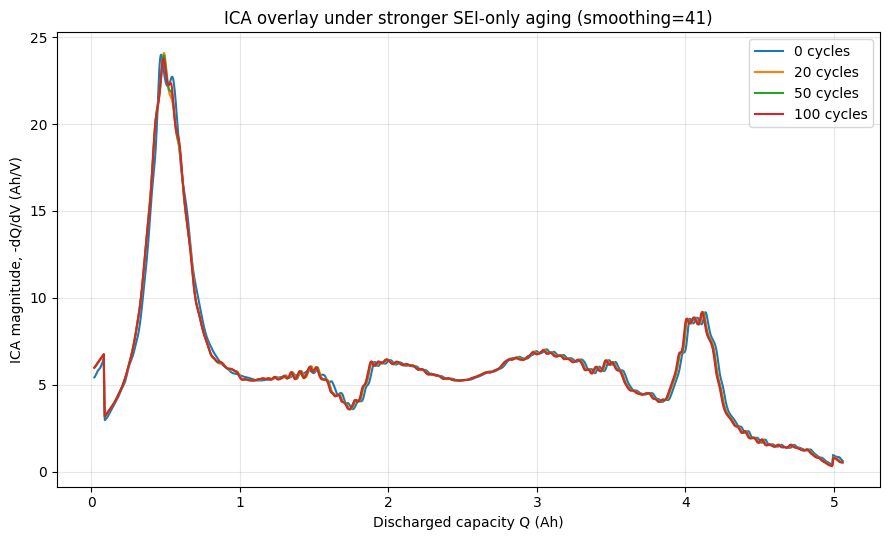

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/derivative_identifiability_ica_overlay.png


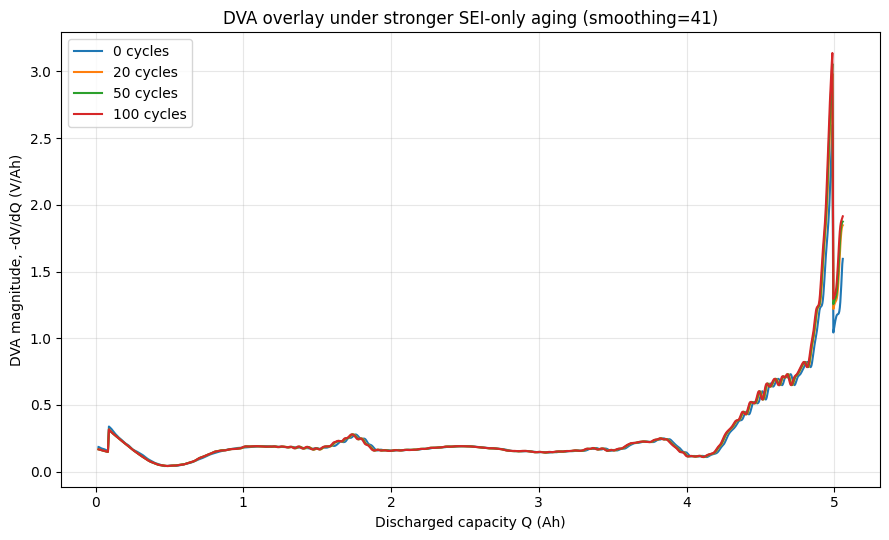

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/derivative_identifiability_dva_overlay.png


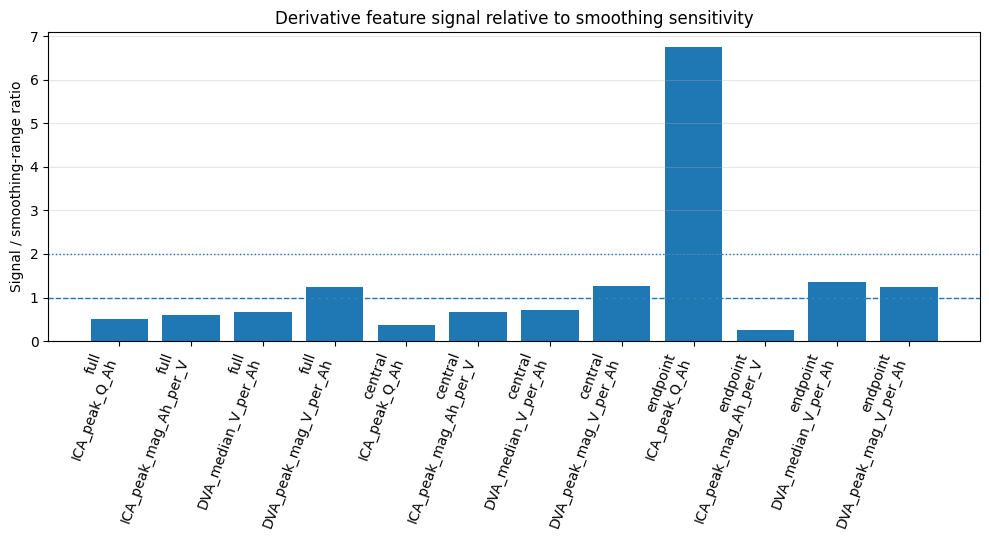

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/derivative_identifiability_signal_vs_smoothing.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_classification_table.csv


,region,feature,signal_to_smoothing_range_ratio,monotonic_fraction_across_smoothing,classification
0,full,ICA_peak_Q_Ah,0.500000,0.25,not reliable as primary fitting target
1,full,ICA_peak_mag_Ah_per_V,0.603337,0.25,not reliable as primary fitting target
2,full,DVA_median_V_per_Ah,0.674481,0.25,not reliable as primary fitting target
3,full,DVA_peak_mag_V_per_Ah,1.252167,1.00,conditional auxiliary target
4,central,ICA_peak_Q_Ah,0.375000,0.75,not reliable as primary fitting target
5,central,ICA_peak_mag_Ah_per_V,0.671320,0.50,not reliable as primary fitting target
6,central,DVA_median_V_per_Ah,0.722809,0.75,not reliable as primary fitting target
7,central,DVA_peak_mag_V_per_Ah,1.275445,1.00,conditional auxiliary target
8,endpoint,ICA_peak_Q_Ah,6.750000,0.75,candidate fitting target
9,endpoint,ICA_peak_mag_Ah_per_V,0.263454,1.00,not reliable as primary fitting target


,metric_layer,evidence,strength,classification
0,smoothing_sensitivity,Derivative feature signals were compared again...,audit-level,smoothing sensitivity explicitly audited
1,endpoint_control,"Full, central, and endpoint Q-regions were eva...",critical boundary,endpoint-region artifacts explicitly controlled
2,candidate_features,1 feature-region combinations classified as ca...,weakly supported,derivative features are usable only as auxilia...
3,overall,ICA/DVA features were audited for identifiabil...,weakly supported,derivative features are usable only as auxilia...
4,full,ICA_peak_Q_Ah,0.5,not reliable as primary fitting target
5,full,ICA_peak_mag_Ah_per_V,0.603337,not reliable as primary fitting target
6,full,DVA_median_V_per_Ah,0.674481,not reliable as primary fitting target
7,full,DVA_peak_mag_V_per_Ah,1.252167,conditional auxiliary target
8,central,ICA_peak_Q_Ah,0.375,not reliable as primary fitting target
9,central,ICA_peak_mag_Ah_per_V,0.67132,not reliable as primary fitting target


[OK] Provisional derivative-feature identifiability classification complete.


In [7]:
# Cell 7 — Provisional derivative-feature identifiability classification and figures（微分特征可识别性初步分类与图像）

# Choose reference smoothing window consistent with Notebook 17/18
REF_SMOOTHING_WINDOW = 41

ref_curves = derivative_curve_table[
    derivative_curve_table["smoothing_window"] == REF_SMOOTHING_WINDOW
].copy()

# Figure 1 — ICA overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in ref_curves.groupby("cycle"):
    plt.plot(
        g["Q_dis_Ah"],
        g["ICA_discharge_mag_Ah_per_V"],
        label=f"{cycle} cycles"
    )
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("ICA magnitude, -dQ/dV (Ah/V)")
plt.title(f"ICA overlay under stronger SEI-only aging (smoothing={REF_SMOOTHING_WINDOW})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "derivative_identifiability_ica_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — DVA overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in ref_curves.groupby("cycle"):
    plt.plot(
        g["Q_dis_Ah"],
        g["DVA_discharge_mag_V_per_Ah"],
        label=f"{cycle} cycles"
    )
plt.xlabel("Discharged capacity Q (Ah)")
plt.ylabel("DVA magnitude, -dV/dQ (V/Ah)")
plt.title(f"DVA overlay under stronger SEI-only aging (smoothing={REF_SMOOTHING_WINDOW})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "derivative_identifiability_dva_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — signal-to-smoothing ratio for selected features
ratio_rows = []

for _, row in derivative_signal_audit.iterrows():
    region = row["region"]
    for feat in [
        "ICA_peak_Q_Ah",
        "ICA_peak_mag_Ah_per_V",
        "DVA_median_V_per_Ah",
        "DVA_peak_mag_V_per_Ah",
    ]:
        ratio_rows.append({
            "region": region,
            "feature": feat,
            "signal_to_smoothing_range_ratio": row[f"{feat}_signal_to_smoothing_range_ratio"],
            "monotonic_fraction": row[f"{feat}_monotonic_fraction_across_smoothing"],
        })

ratio_table = pd.DataFrame(ratio_rows)

plt.figure(figsize=(10, 5.5))
x_labels = [f"{r['region']}\n{r['feature']}" for _, r in ratio_table.iterrows()]
x = np.arange(len(x_labels))
plt.bar(x, ratio_table["signal_to_smoothing_range_ratio"])
plt.axhline(1.0, linewidth=1, linestyle="--")
plt.axhline(2.0, linewidth=1, linestyle=":")
plt.xticks(x, x_labels, rotation=70, ha="right")
plt.ylabel("Signal / smoothing-range ratio")
plt.title("Derivative feature signal relative to smoothing sensitivity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "derivative_identifiability_signal_vs_smoothing.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Conservative classification logic
classification_rows = []

for _, row in ratio_table.iterrows():
    region = row["region"]
    feature = row["feature"]
    ratio = float(row["signal_to_smoothing_range_ratio"])
    monotonic_fraction = float(row["monotonic_fraction"])

    if np.isinf(ratio):
        ratio_class = "stable/no smoothing-range denominator"
    elif ratio >= 2.0 and monotonic_fraction >= 0.75:
        ratio_class = "candidate fitting target"
    elif ratio >= 1.0 and monotonic_fraction >= 0.5:
        ratio_class = "conditional auxiliary target"
    else:
        ratio_class = "not reliable as primary fitting target"

    classification_rows.append({
        "region": region,
        "feature": feature,
        "signal_to_smoothing_range_ratio": ratio,
        "monotonic_fraction_across_smoothing": monotonic_fraction,
        "classification": ratio_class,
    })

feature_classification = pd.DataFrame(classification_rows)

# Integrated conclusion
n_candidate = int((feature_classification["classification"] == "candidate fitting target").sum())
n_conditional = int((feature_classification["classification"] == "conditional auxiliary target").sum())

if n_candidate >= 2:
    overall_strength = "partially supported"
    overall_classification = "selected derivative features may serve as conditional fitting targets"
elif n_candidate + n_conditional >= 2:
    overall_strength = "weakly supported"
    overall_classification = "derivative features are usable only as auxiliary descriptors"
else:
    overall_strength = "not supported"
    overall_classification = "derivative features are not reliable primary fitting targets under stronger SEI-only aging"

summary_rows = [
    {
        "metric_layer": "smoothing_sensitivity",
        "evidence": "Derivative feature signals were compared against smoothing-window variability.",
        "strength": "audit-level",
        "classification": "smoothing sensitivity explicitly audited",
    },
    {
        "metric_layer": "endpoint_control",
        "evidence": "Full, central, and endpoint Q-regions were evaluated separately.",
        "strength": "critical boundary",
        "classification": "endpoint-region artifacts explicitly controlled",
    },
    {
        "metric_layer": "candidate_features",
        "evidence": f"{n_candidate} feature-region combinations classified as candidate fitting targets; {n_conditional} as conditional auxiliary targets.",
        "strength": overall_strength,
        "classification": overall_classification,
    },
    {
        "metric_layer": "overall",
        "evidence": "ICA/DVA features were audited for identifiability under 0/20/50/100-cycle SEI-only aging.",
        "strength": overall_strength,
        "classification": overall_classification,
    },
]

classification_table = pd.concat([
    pd.DataFrame(summary_rows),
    feature_classification.rename(columns={
        "region": "metric_layer",
        "feature": "evidence",
        "signal_to_smoothing_range_ratio": "strength",
        "classification": "classification",
    })[["metric_layer", "evidence", "strength", "classification"]]
], ignore_index=True)

classification_path = DATA / "derivative_identifiability_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")

display(feature_classification)
display(classification_table.head(20))

print("[OK] Provisional derivative-feature identifiability classification complete.")

In [8]:
# Cell 8 — Fitting-target hierarchy and revised derivative identifiability classification
# （拟合目标层级与修正后的微分特征可识别性分类）

# Pull key already-audited reference values
capacity_100 = capacity_rpt_table[capacity_rpt_table["cycle"] == 100].iloc[0]
c25_100 = c25_central_drift_audit[c25_central_drift_audit["cycle"] == 100].iloc[0]
gitt_100 = gitt_drift_audit[gitt_drift_audit["cycle"] == 100].iloc[0]

capacity_fade_100_pct = float(capacity_100["capacity_fade_pct"])
capacity_loss_100_Ah = float(capacity_100["capacity_loss_Ah_vs_0"])

c25_central_mean_100_mV = float(c25_100["central_deltaU_mean_mV"])
c25_central_p95_100_mV = float(c25_100["central_deltaU_p95_abs_mV"])
c25_endpoint_p95_100_mV = float(c25_100["endpoint_deltaU_p95_abs_mV"])

gitt_mean_100_mV = float(gitt_100["deltaU_mean_mV"])
gitt_p95_100_mV = float(gitt_100["deltaU_p95_abs_mV"])

# Summarize derivative endpoint-confounding
feature_classification_clean = feature_classification.copy()

# Reclassify endpoint-derived candidate features as endpoint-confounded
feature_classification_clean["revised_classification"] = feature_classification_clean["classification"]

endpoint_candidate_mask = (
    (feature_classification_clean["region"] == "endpoint")
    & (feature_classification_clean["classification"] == "candidate fitting target")
)

feature_classification_clean.loc[
    endpoint_candidate_mask,
    "revised_classification"
] = "endpoint-confounded candidate; not recommended as primary target"

# If a derivative feature is conditional in endpoint, also mark it as endpoint-sensitive auxiliary.
endpoint_aux_mask = (
    (feature_classification_clean["region"] == "endpoint")
    & (feature_classification_clean["classification"] == "conditional auxiliary target")
)

feature_classification_clean.loc[
    endpoint_aux_mask,
    "revised_classification"
] = "endpoint-sensitive auxiliary target"

revised_feature_class_path = DATA / "derivative_identifiability_revised_feature_classification.csv"
feature_classification_clean.to_csv(revised_feature_class_path, index=False)

print(f"[OK] saved: {revised_feature_class_path}")
display(feature_classification_clean)

n_primary_reliable = int(
    (
        feature_classification_clean["revised_classification"]
        == "candidate fitting target"
    ).sum()
)

n_endpoint_confounded = int(endpoint_candidate_mask.sum())
n_auxiliary = int(
    feature_classification_clean["revised_classification"]
    .str.contains("auxiliary", case=False, na=False)
    .sum()
)

# Build fitting-target hierarchy for Porsche-style parameterization logic
hierarchy_rows = [
    {
        "rank": 1,
        "target_layer": "capacity_RPT",
        "candidate_target": "external discharge capacity / capacity fade",
        "evidence": (
            f"100-cycle capacity fade = {capacity_fade_100_pct:.4f} %, "
            f"capacity loss = {capacity_loss_100_Ah:.6f} Ah; monotonic across 0/20/50/100 cycles."
        ),
        "fitting_target_role": "primary target",
        "reason": (
            "Strongest downstream observable; directly degradation-sensitive; "
            "low derivative-processing sensitivity."
        ),
        "porsche_relevance": (
            "Suitable as a robust measurement-level target for aging-model calibration "
            "and system-level SOH validation."
        ),
    },
    {
        "rank": 2,
        "target_layer": "GITT_like_finite_rest",
        "candidate_target": "finite-rest OCV-like voltage points",
        "evidence": (
            f"100-cycle mean ΔU = {gitt_mean_100_mV:.3f} mV; "
            f"p95 |ΔU| = {gitt_p95_100_mV:.3f} mV; monotonic but weak."
        ),
        "fitting_target_role": "secondary target",
        "reason": (
            "Cleaner than C/25 endpoint region; less cutoff-amplified; "
            "but signal magnitude remains weak."
        ),
        "porsche_relevance": (
            "Useful as a quasi-equilibrium voltage-shape constraint for model validation, "
            "not as sole optimization target."
        ),
    },
    {
        "rank": 3,
        "target_layer": "C25_central_VQ",
        "candidate_target": "central-window OCV-like V(Q)",
        "evidence": (
            f"100-cycle central-window mean ΔU = {c25_central_mean_100_mV:.3f} mV; "
            f"central p95 |ΔU| = {c25_central_p95_100_mV:.3f} mV."
        ),
        "fitting_target_role": "secondary / conditional target",
        "reason": (
            "Aging-sensitive after endpoint control; central signal moderate; "
            "full-window interpretation is endpoint-amplified."
        ),
        "porsche_relevance": (
            "Useful for protocol-sensitive voltage validation if common-Q and endpoint controls are enforced."
        ),
    },
    {
        "rank": 4,
        "target_layer": "C25_endpoint_VQ",
        "candidate_target": "low-voltage endpoint drift",
        "evidence": (
            f"100-cycle endpoint p95 |ΔU| = {c25_endpoint_p95_100_mV:.3f} mV."
        ),
        "fitting_target_role": "boundary diagnostic only",
        "reason": (
            "Large signal but dominated by cutoff-boundary amplification; "
            "not suitable as primary electrochemical parameterization target."
        ),
        "porsche_relevance": (
            "Useful for usable-capacity / voltage-boundary analysis, not direct mechanism calibration."
        ),
    },
    {
        "rank": 5,
        "target_layer": "ICA_DVA_derivatives",
        "candidate_target": "ICA/DVA peak and median features",
        "evidence": (
            f"Reliable non-endpoint primary derivative targets = {n_primary_reliable}; "
            f"endpoint-confounded candidates = {n_endpoint_confounded}; "
            f"auxiliary derivative targets = {n_auxiliary}."
        ),
        "fitting_target_role": "auxiliary audit only",
        "reason": (
            "Most derivative features have aging signal comparable to or smaller than smoothing sensitivity; "
            "endpoint candidates are confounded by cutoff-region amplification."
        ),
        "porsche_relevance": (
            "Use for diagnostic visualization and consistency checks, not as primary optimization targets "
            "under mild/moderate SEI-only aging."
        ),
    },
]

fitting_target_hierarchy = pd.DataFrame(hierarchy_rows)

hierarchy_path = DATA / "derivative_identifiability_fitting_target_hierarchy.csv"
fitting_target_hierarchy.to_csv(hierarchy_path, index=False)

print(f"[OK] saved: {hierarchy_path}")
display(fitting_target_hierarchy)

# Revised notebook-level classification
revised_classification_rows = [
    {
        "metric_layer": "capacity_RPT",
        "evidence": (
            f"100-cycle capacity fade = {capacity_fade_100_pct:.4f} %, "
            f"capacity loss = {capacity_loss_100_Ah:.6f} Ah."
        ),
        "strength": "strong",
        "classification": "recommended primary fitting target",
    },
    {
        "metric_layer": "GITT_like_finite_rest",
        "evidence": (
            f"100-cycle mean ΔU = {gitt_mean_100_mV:.3f} mV; "
            f"p95 |ΔU| = {gitt_p95_100_mV:.3f} mV."
        ),
        "strength": "moderate / clean but weak",
        "classification": "recommended secondary voltage target",
    },
    {
        "metric_layer": "C25_central_VQ",
        "evidence": (
            f"100-cycle central-window mean ΔU = {c25_central_mean_100_mV:.3f} mV; "
            f"central p95 |ΔU| = {c25_central_p95_100_mV:.3f} mV."
        ),
        "strength": "moderate / protocol-sensitive",
        "classification": "conditional secondary target with endpoint control",
    },
    {
        "metric_layer": "ICA_DVA",
        "evidence": (
            "Most full/central derivative features show signal-to-smoothing ratios below 1; "
            "endpoint ICA peak-Q candidate is endpoint-confounded."
        ),
        "strength": "weak",
        "classification": "not recommended as primary fitting targets under stronger SEI-only aging",
    },
    {
        "metric_layer": "overall",
        "evidence": (
            "Derivative features were audited against smoothing-window sensitivity, endpoint regions, "
            "common-Q control, capacity RPT, C/25 central drift, and GITT-like finite-rest drift."
        ),
        "strength": "data-backed",
        "classification": (
            "SEI-only parameterization should prioritize capacity RPT and secondary voltage-shape targets; "
            "ICA/DVA should remain auxiliary."
        ),
    },
]

revised_classification_table = pd.DataFrame(revised_classification_rows)

revised_classification_path = DATA / "derivative_identifiability_revised_classification_table.csv"
revised_classification_table.to_csv(revised_classification_path, index=False)

print(f"[OK] saved: {revised_classification_path}")
display(revised_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_revised_feature_classification.csv


,region,feature,signal_to_smoothing_range_ratio,monotonic_fraction_across_smoothing,classification,revised_classification
0,full,ICA_peak_Q_Ah,0.500000,0.25,not reliable as primary fitting target,not reliable as primary fitting target
1,full,ICA_peak_mag_Ah_per_V,0.603337,0.25,not reliable as primary fitting target,not reliable as primary fitting target
2,full,DVA_median_V_per_Ah,0.674481,0.25,not reliable as primary fitting target,not reliable as primary fitting target
3,full,DVA_peak_mag_V_per_Ah,1.252167,1.00,conditional auxiliary target,conditional auxiliary target
4,central,ICA_peak_Q_Ah,0.375000,0.75,not reliable as primary fitting target,not reliable as primary fitting target
5,central,ICA_peak_mag_Ah_per_V,0.671320,0.50,not reliable as primary fitting target,not reliable as primary fitting target
6,central,DVA_median_V_per_Ah,0.722809,0.75,not reliable as primary fitting target,not reliable as primary fitting target
7,central,DVA_peak_mag_V_per_Ah,1.275445,1.00,conditional auxiliary target,conditional auxiliary target
8,endpoint,ICA_peak_Q_Ah,6.750000,0.75,candidate fitting target,endpoint-confounded candidate; not recommended...
9,endpoint,ICA_peak_mag_Ah_per_V,0.263454,1.00,not reliable as primary fitting target,not reliable as primary fitting target


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_fitting_target_hierarchy.csv


,rank,target_layer,candidate_target,evidence,fitting_target_role,reason,porsche_relevance
0,1,capacity_RPT,external discharge capacity / capacity fade,"100-cycle capacity fade = 0.4696 %, capacity l...",primary target,Strongest downstream observable; directly degr...,Suitable as a robust measurement-level target ...
1,2,GITT_like_finite_rest,finite-rest OCV-like voltage points,100-cycle mean ΔU = -2.280 mV; p95 |ΔU| = 4.14...,secondary target,Cleaner than C/25 endpoint region; less cutoff...,Useful as a quasi-equilibrium voltage-shape co...
2,3,C25_central_VQ,central-window OCV-like V(Q),100-cycle central-window mean ΔU = -2.694 mV; ...,secondary / conditional target,Aging-sensitive after endpoint control; centra...,Useful for protocol-sensitive voltage validati...
3,4,C25_endpoint_VQ,low-voltage endpoint drift,100-cycle endpoint p95 |ΔU| = 102.539 mV.,boundary diagnostic only,Large signal but dominated by cutoff-boundary ...,Useful for usable-capacity / voltage-boundary ...
4,5,ICA_DVA_derivatives,ICA/DVA peak and median features,Reliable non-endpoint primary derivative targe...,auxiliary audit only,Most derivative features have aging signal com...,Use for diagnostic visualization and consisten...


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_revised_classification_table.csv


,metric_layer,evidence,strength,classification
0,capacity_RPT,"100-cycle capacity fade = 0.4696 %, capacity l...",strong,recommended primary fitting target
1,GITT_like_finite_rest,100-cycle mean ΔU = -2.280 mV; p95 |ΔU| = 4.14...,moderate / clean but weak,recommended secondary voltage target
2,C25_central_VQ,100-cycle central-window mean ΔU = -2.694 mV; ...,moderate / protocol-sensitive,conditional secondary target with endpoint con...
3,ICA_DVA,Most full/central derivative features show sig...,weak,not recommended as primary fitting targets und...
4,overall,Derivative features were audited against smoot...,data-backed,SEI-only parameterization should prioritize ca...


In [9]:
# Cell 9 — Notebook 22 output inventory audit（Notebook 22 输出文件清单审计）

expected_outputs = [
    DATA / "derivative_identifiability_common_grid_table.csv",
    DATA / "derivative_identifiability_feature_table.csv",
    DATA / "derivative_identifiability_derivative_curve_table.csv",
    DATA / "derivative_identifiability_smoothing_audit.csv",
    DATA / "derivative_identifiability_signal_by_smoothing_table.csv",
    DATA / "derivative_identifiability_signal_audit.csv",
    DATA / "derivative_identifiability_classification_table.csv",
    DATA / "derivative_identifiability_revised_feature_classification.csv",
    DATA / "derivative_identifiability_fitting_target_hierarchy.csv",
    DATA / "derivative_identifiability_revised_classification_table.csv",
    FIGURES / "derivative_identifiability_ica_overlay.png",
    FIGURES / "derivative_identifiability_dva_overlay.png",
    FIGURES / "derivative_identifiability_signal_vs_smoothing.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "derivative_identifiability_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected Notebook 22 output files are missing."
print("[OK] All expected Notebook 22 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/derivative_identifiability_output_inventory.csv


,path,exists,size_kB
0,data/derivative_identifiability_common_grid_ta...,True,234.27
1,data/derivative_identifiability_feature_table.csv,True,10.65
2,data/derivative_identifiability_derivative_cur...,True,1898.95
3,data/derivative_identifiability_smoothing_audi...,True,6.14
4,data/derivative_identifiability_signal_by_smoo...,True,7.20
5,data/derivative_identifiability_signal_audit.csv,True,3.31
6,data/derivative_identifiability_classification...,True,1.65
7,data/derivative_identifiability_revised_featur...,True,1.57
8,data/derivative_identifiability_fitting_target...,True,1.98
9,data/derivative_identifiability_revised_classi...,True,1.00


[OK] All expected Notebook 22 outputs exist.


## Final closure — Notebook 22

### Key findings

Notebook 22 audited whether ICA/DVA derivative voltage features under stronger SEI-only aging are stable enough to serve as fitting targets for aging-model parameterization.

The notebook did not run new aging simulations. It used audited outputs from Notebook 21, including:

- C/25 OCV-like V(Q) curves at 0/20/50/100 cycles;
- C/25 central-window voltage-drift audit;
- GITT-like finite-rest voltage-drift audit;
- capacity RPT table;
- SEI degradation-state table.

The analysis focused on derivative-feature identifiability rather than visual curve generation.

### Aging-evidence and fitting-target rejection rules

A diagnostic feature is **not recommended as primary aging evidence or as a primary fitting target** if any of the following conditions apply:

1. **Signal-to-smoothing-range ratio < 1（信号-平滑敏感性比小于 1）**  
   The aging-induced signal is smaller than the variability introduced by smoothing-window selection.

2. **Monotonic fraction across smoothing < 0.75（跨平滑窗口单调一致性低于 0.75）**  
   The feature does not maintain a stable monotonic aging trend across smoothing settings.

3. **Signal appears only in the endpoint region（信号只出现在端点区域）**  
   The feature is likely affected by cutoff-boundary amplification, usable-capacity shifts, or endpoint curvature.

4. **Strong preprocessing dependence（强数据处理依赖）**  
   The feature changes substantially with smoothing, interpolation, common-Q grid selection, or endpoint truncation.

5. **Weak physical linkage to degradation-state variables（与老化状态变量关联弱）**  
   The feature is not consistently linked to SEI thickness, LLI, lithium loss, SEI capacity loss, or other degradation-state variables.

6. **Mechanism non-uniqueness（机制非唯一性）**  
   The feature can plausibly be produced by multiple degradation mechanisms, including SEI growth, lithium plating, LAM, or resistance growth.

7. **Signal magnitude below protocol sensitivity（信号幅度低于协议敏感性）**  
   The feature drift is smaller than the sensitivity introduced by the diagnostic protocol itself.

### Derivative-feature audit results

Most full-window and central-window ICA/DVA features were not suitable as primary fitting targets.

Examples:

- full-window ICA peak-Q signal-to-smoothing ratio ≈ 0.50;
- central-window ICA peak-Q signal-to-smoothing ratio ≈ 0.375;
- central-window DVA median signal-to-smoothing ratio ≈ 0.723.

These values are below 1, meaning that aging-induced feature drift is comparable to or smaller than smoothing-window sensitivity.

DVA peak magnitude showed conditional auxiliary value:

- full-window DVA peak ratio ≈ 1.25;
- central-window DVA peak ratio ≈ 1.28.

However, peak-type features remain curvature-sensitive and should not be used as primary fitting targets.

Endpoint ICA peak-Q showed a high ratio of approximately 6.75, but this feature originates from the endpoint region. Because Notebook 21 already established strong endpoint amplification in C/25 full-window V(Q), this feature was reclassified as:

`endpoint-confounded candidate; not recommended as primary target`

### Fitting-target hierarchy

The recommended fitting-target hierarchy for SEI-only aging is:

1. **Capacity RPT（容量 RPT）**  
   Recommended primary measurement-level fitting target.

2. **GITT-like finite-rest voltage points（GITT-like 有限静置电压点）**  
   Recommended secondary voltage-shape target. Cleaner than endpoint-amplified C/25 drift, but weak.

3. **C/25 central-window V(Q)（C/25 中央窗口电压曲线）**  
   Conditional secondary voltage-shape target. Aging-sensitive after endpoint control, but protocol-sensitive.

4. **C/25 endpoint V(Q)（C/25 端点电压漂移）**  
   Boundary diagnostic only. Large signal, but dominated by cutoff-boundary amplification.

5. **ICA/DVA derivative features（ICA/DVA 微分特征）**  
   Auxiliary audit descriptors only. Not recommended as primary optimization targets under stronger SEI-only aging.

### Correct conclusion wording

Supported:

- Capacity RPT is the strongest and cleanest primary fitting target for SEI-only aging.
- GITT-like finite-rest voltage points can be used as secondary voltage-shape constraints.
- C/25 central-window V(Q) can be used as a conditional secondary target if endpoint control is enforced.
- ICA/DVA can be generated and audited, but should remain auxiliary descriptors.

Not supported:

- ICA/DVA features are not robust primary fitting targets under the tested SEI-only aging branch.
- Endpoint derivative features should not be interpreted as direct electrochemical aging evidence.
- Derivative peak positions should not be used for primary parameterization without smoothing and endpoint controls.
- This notebook does not establish mechanism-unique SEI fingerprints.

### Project-level classification

`SEI-only parameterization target hierarchy = capacity-first, voltage-shape secondary, derivative auxiliary`

Project-level wording:

> For SEI-only aging, capacity RPT should be prioritized as the primary fitting target. GITT-like finite-rest voltage points and C/25 central-window V(Q) can serve as secondary voltage-shape constraints. ICA/DVA derivative features are not reliable enough for primary aging-model parameterization under the tested stronger SEI-only aging branch and should remain auxiliary audit descriptors.

### Porsche-oriented interpretation

This notebook supports a Porsche-style aging-modeling workflow by separating robust fitting targets from fragile diagnostic descriptors.

The result shows that model parameterization should not blindly use all available voltage-derived features. Instead, each candidate observable must be audited for smoothing sensitivity, endpoint confounding, physical linkage, mechanism uniqueness, and protocol sensitivity before it enters an optimization objective.

This directly supports the transition from simulation outputs to measurement-based model calibration and system-relevant validation.